# 🧠 Predicción de Series Temporales con LSTM (PyTorch)
---
**Dataset:** Temperaturas Mínimas Diarias — Melbourne, Australia  
**Objetivo:** Entrenar una red neuronal recurrente LSTM para aprender patrones temporales.

> **LSTM** (*Long Short-Term Memory*) es un tipo de red neuronal recurrente (RNN) diseñada para capturar **dependencias de largo plazo** en secuencias. A diferencia de las RNNs simples, las LSTMs utilizan un sistema de "puertas" (forget, input, output) que controla qué información retener y qué descartar.

**Ventaja clave:** puede aprender patrones temporales complejos y no lineales que los modelos estadísticos clásicos no capturan.

**Referencia oficial PyTorch:** https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html

---

## 1. Importación de Librerías y Configuración de Semillas

Fijamos semillas aleatorias para garantizar **reproducibilidad** de los resultados.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
%matplotlib inline

# Semillas para reproducibilidad
torch.manual_seed(0)
np.random.seed(0)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


## 2. Carga y Limpieza del Dataset

> ⚠️ **Fix aplicado:** El dataset original contiene registros con valores no numéricos (e.g., `"?"`) que generan `NaN` durante el procesamiento. Aplicamos `dropna()` y conversión explícita para garantizar datos limpios desde el inicio.

In [2]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")

# Fix NaN: eliminamos filas con valores faltantes o no numéricos
data.iloc[:, 1] = pd.to_numeric(data.iloc[:, 1], errors='coerce')
data = data.dropna()
data = data.reset_index(drop=True)

print(f"Dataset limpio: {data.shape[0]} registros válidos")
data.head()

Dataset limpio: 3647 registros válidos


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### 2.1 Visualización de la Serie Temporal

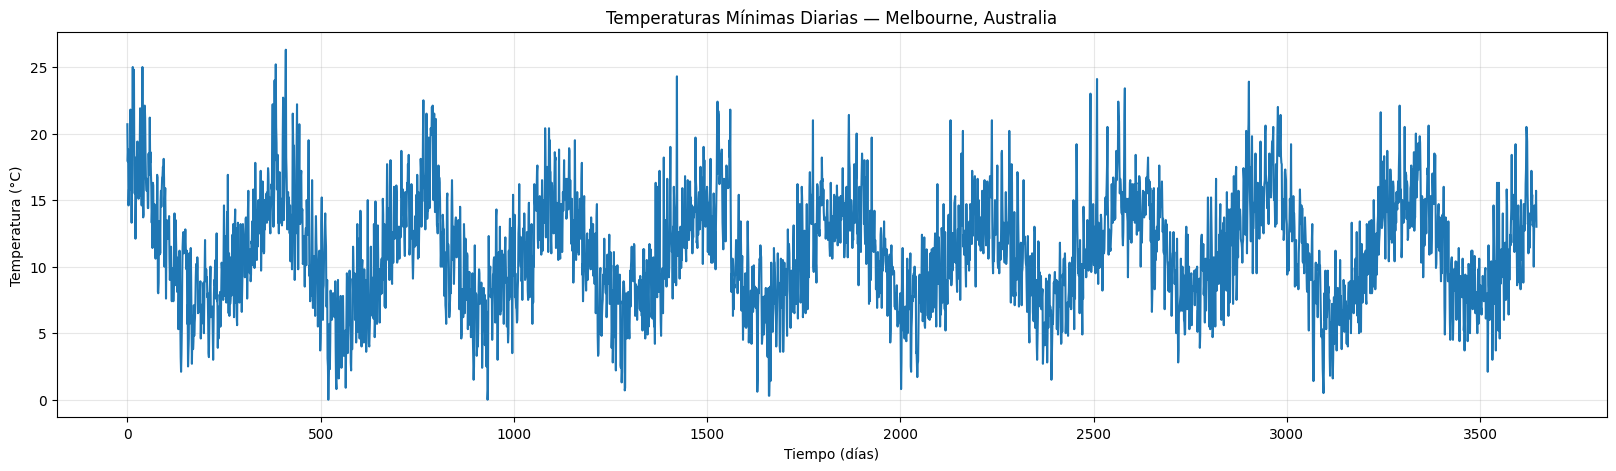

In [3]:
plt.figure(figsize=(20, 5))
plt.plot(pd.to_numeric(data.iloc[:, 1], errors='coerce'))
plt.title("Temperaturas Mínimas Diarias — Melbourne, Australia")
plt.xlabel("Tiempo (días)")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.show()

## 3. División Train / Test y Normalización

### ¿Por qué normalizar?
Las LSTMs son sensibles a la escala de los datos. Normalizamos al rango `[-1, 1]` para:
- Mejorar la convergencia del gradiente.
- Evitar que valores grandes dominen el aprendizaje.

> **Importante:** ajustamos el scaler **solo con datos de train** para evitar *data leakage*.

In [4]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = pd.to_numeric(data.iloc[:train_size, 1], errors='coerce').dropna().values.astype(float)
test = pd.to_numeric(data.iloc[train_size:, 1], errors='coerce').dropna().values.astype(float)

# Normalización [-1, 1] — el scaler se ajusta SOLO con train
sc = MinMaxScaler(feature_range=(-1, 1))
train_norm = sc.fit_transform(train.reshape(-1, 1))
train_norm = torch.FloatTensor(train_norm).view(-1)

print(f"Train: {len(train)} muestras | Test: {len(test)} muestras")
print(f"Rango train normalizado: [{train_norm.min():.2f}, {train_norm.max():.2f}]")

Train: 2443 muestras | Test: 1204 muestras
Rango train normalizado: [-1.00, 1.00]


## 4. Creación de Secuencias de Entrada/Salida

Las LSTMs aprenden de **ventanas deslizantes**: dados los últimos `window` días, predecimos el valor `ndays` días en el futuro.

```
[día 1, día 2, ..., día 30] → predice día 36  (window=30, ndays=5)
[día 2, día 3, ..., día 31] → predice día 37
...
```

In [5]:
def create_input_output(input_data, window, ndays=1):
    """
    Genera pares (secuencia_entrada, etiqueta) desplazados por ndays.
    
    Args:
        input_data: tensor o array con la serie normalizada
        window: longitud de la ventana de entrada
        ndays: distancia en días al punto a predecir
    Returns:
        Lista de tuplas (input_seq, label)
    """
    input_output = []
    data_size = len(input_data)
    for i in range(data_size - window - ndays):
        train_seq = input_data[i:i+window]
        train_label = input_data[i+window+ndays:i+window+ndays+1]
        input_output.append((train_seq, train_label))
    return input_output

ndays = 5
window = 30

train_input_output = create_input_output(train_norm, window, ndays)
print(f"Pares de entrenamiento generados: {len(train_input_output)}")
print(f"Forma entrada: {train_input_output[0][0].shape} | Forma etiqueta: {train_input_output[0][1].shape}")

Pares de entrenamiento generados: 2408
Forma entrada: torch.Size([30]) | Forma etiqueta: torch.Size([1])


In [6]:
len(train_input_output), len(train_input_output[0]), np.shape(train_input_output[0][0]), np.shape(train_input_output[0][1])

(2408, 2, torch.Size([30]), torch.Size([1]))

## 5. Definición de la Arquitectura LSTM

La red tiene:
1. **Capa LSTM:** procesa la secuencia de longitud `window` con 100 unidades ocultas.
2. **Capa Linear:** convierte el estado oculto final en la predicción escalar.

In [8]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        
        # Capa LSTM: procesa la secuencia temporal
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        
        # Capa de salida: proyecta el estado oculto en la predicción
        self.linear = nn.Linear(hidden_layer_size, output_size)
        
    def forward(self, input_seq):
        # La LSTM espera forma (seq_len, batch_size, input_size)
        lstm_out, _ = self.lstm(input_seq.view(len(input_seq), 1, -1))
        
        # Capa lineal sobre toda la secuencia
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        
        # Retornamos solo la predicción del último paso temporal
        return predictions[-1]

model = LSTM()
print(model)
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

LSTM(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)
Parámetros totales: 41,301


## 6. Entrenamiento del Modelo

Usamos:
- **Función de pérdida:** `MSELoss` — minimiza el error cuadrático entre predicción y valor real.
- **Optimizador:** `Adam` con learning rate `0.001` — adaptativo y eficiente para RNNs.

In [17]:
model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
print(f"Entrenando por {epochs} epochs con {len(train_input_output)} secuencias...")

for i in range(epochs):
    for inputs, labels in train_input_output:
        optimizer.zero_grad()
        y_pred = model(inputs)
        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()
        
    print(f'epoch: {i+1:3} | loss: {single_loss.item():10.8f}')

print("✅ Entrenamiento completado")


Entrenando por 10 epochs con 2408 secuencias...
epoch:   1 | loss: 0.00757626
epoch:   2 | loss: 0.00565991
epoch:   3 | loss: 0.00672422
epoch:   4 | loss: 0.00464100
epoch:   5 | loss: 0.00413450
epoch:   6 | loss: 0.00405370
epoch:   7 | loss: 0.00381236
epoch:   8 | loss: 0.00380594
epoch:   9 | loss: 0.00365491
epoch:  10 | loss: 0.00358339
✅ Entrenamiento completado


## 7. Evaluación sobre el Set de Test

Aplicamos el mismo pipeline al set de test:
1. Normalizar con el scaler de train.
2. Crear secuencias deslizantes.
3. Predecir con `torch.no_grad()` para ahorrar memoria.
4. Des-normalizar las predicciones.

In [18]:
# Normalización del test (usando el scaler ajustado en train)
test_norm = sc.transform(np.asarray(test, dtype=float).reshape(-1, 1))
test_norm = torch.FloatTensor(test_norm).view(-1)

test_input_output = create_input_output(test_norm, window, ndays)
print(f"Pares de test: {len(test_input_output)}")

Pares de test: 1169


In [19]:
# Inferencia
y_pred_norm = []
model.eval()
for inputs, labels in test_input_output:
    with torch.no_grad():
        y_pred_norm.append(model(inputs).item())

print(f"Predicciones normalizadas (primeras 5): {y_pred_norm[:5]}")

Predicciones normalizadas (primeras 5): [-0.3919346332550049, -0.4051399827003479, -0.34625744819641113, -0.3195202648639679, -0.3356465697288513]


In [20]:
# Des-normalización
y_pred = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))
print(f"Predicciones en °C (primeras 5): {y_pred[:5].flatten()}")

Predicciones en °C (primeras 5): [7.99605957 7.82240923 8.59671456 8.94830852 8.73624761]


## 8. Cálculo del MSE y Visualización

Alineamos las predicciones con los valores reales correspondientes del test set.

In [21]:
y_true = np.asarray(test[window + ndays:], dtype=float).reshape(-1)
y_pred_1d = np.asarray(y_pred, dtype=float).reshape(-1)

# Aseguramos misma longitud
min_len = min(len(y_true), len(y_pred_1d))
y_true = y_true[:min_len]
y_pred_1d = y_pred_1d[:min_len]

mse = mean_squared_error(y_true, y_pred_1d)
rmse = mse ** 0.5

print(f"📊 MSE  : {mse:.4f}")
print(f"📊 RMSE : {rmse:.4f} °C")

📊 MSE  : 9.6614
📊 RMSE : 3.1083 °C


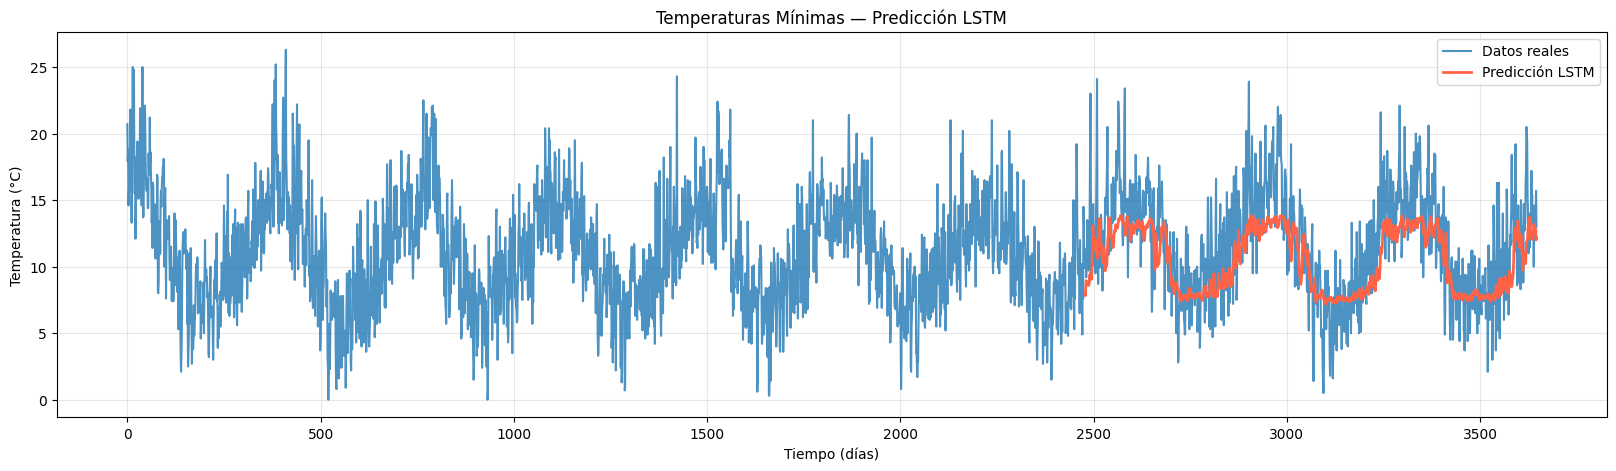

In [22]:
plt.figure(figsize=(20, 5))

# Serie original completa
plt.plot(pd.to_numeric(data.iloc[:, 1], errors='coerce'), label="Datos reales", alpha=0.8)

# Predicción LSTM
pred_start = len(train) + window + ndays
pred_end = pred_start + len(y_pred_1d)
plt.plot(range(pred_start, pred_end), y_pred_1d, label="Predicción LSTM", color="tomato", linewidth=2)

plt.title("Temperaturas Mínimas — Predicción LSTM")
plt.xlabel("Tiempo (días)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## 9. ¿Cuándo usar LSTM? — Comparativa con otros modelos

### ✅ Ventajas de LSTM
| Criterio | LSTM |
|---|---|
| **Captura de dependencias largas** | ⭐⭐⭐⭐⭐ — Diseñada para esto |
| **Modelado no lineal** | ⭐⭐⭐⭐⭐ — Aprende relaciones complejas |
| **Adaptabilidad** | ⭐⭐⭐⭐ — Sirve para texto, audio, series temporales |
| **Velocidad de entrenamiento** | ⭐⭐ — Requiere más tiempo y datos que modelos estadísticos |
| **Interpretabilidad** | ⭐ — Es una "caja negra" |

### 🆚 Comparativa con los otros modelos del curso

| Modelo | Tipo | Dependencias temporales | Requiere GPU |
|---|---|---|---|
| **ARIMA** | Estadístico | Cortas (p lags) | No |
| **Prophet** | Descomposición | Estacionalidades fijas | No |
| **LSTM** *(este)* | Deep Learning RNN | **Largas y complejas** | Recomendado |
| **CNN 1D** | Deep Learning | **Locales (kernel size)** | Recomendado |

### 💡 ¿Cuándo elegir LSTM?
- Cuando la serie tiene **dependencias temporales largas** (el pasado lejano importa).
- Cuando los patrones son **no lineales y complejos**.
- Cuando tenés suficientes datos (> 1000 puntos) para entrenar correctamente.
- Para tareas de **predicción multi-paso** (predecir varios días a futuro).
